Linear Regression Model

Train size: (1408, 11)
Test size : (289, 11)
MSE  : 14512782.96
RMSE : 3809.56
R²   : 0.6155
MAE  : 2889.95


,Datum,Ist,Vorhersage
1408,2025-01-01,9044.4,24844.863174
1409,2025-01-02,7072.0,10407.807797
1410,2025-01-03,5737.6,7814.614450
1411,2025-01-04,12210.0,7021.052609
1412,2025-01-05,5389.9,7611.578975
1413,2025-01-06,5189.4,5723.668578
1414,2025-01-07,3482.0,17577.065908
1415,2025-01-08,3186.7,4517.143175
1416,2025-01-09,5361.6,4163.904039
1417,2025-01-10,7683.8,5727.191860


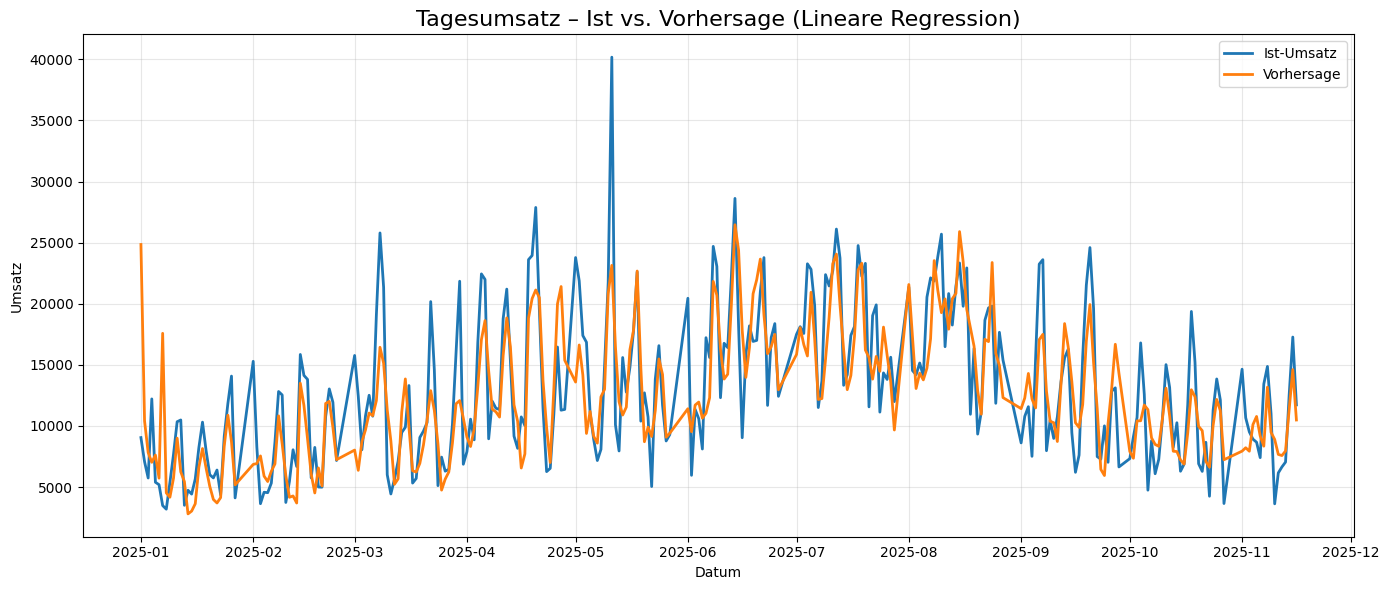

In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# 1) Daten laden
df = pd.read_csv("data/dataset-merged-2.csv")
# Datum konvertieren & sortieren
df["Datum"] = pd.to_datetime(df["Datum"])
df = df.sort_values("Datum")

# 2) Zielvariable definieren
target = "Tagesumsatz Restaurant"

# 3) Lag-Features
df["lag1"] = df[target].shift(1)
df["lag2"] = df[target].shift(2)
df["lag7"] = df[target].shift(7)
df["lag30"] = df[target].shift(30)

# Lags erzeugen NaN → entfernen
df = df.dropna().reset_index(drop=True)

# 4) Feature-Auswahl
num_cols = df.select_dtypes(include=["number"]).columns

cols_to_exclude = ["Tagesumsatz Restaurant", "Restaurant", "Terrasse"]

feature_cols = [c for c in num_cols if c not in cols_to_exclude]

X = df[feature_cols]
y = df[target]

# 5) Zeitbasiertes Train/Test-Split
split_date = pd.Timestamp("2025-01-01")

train_mask = df["Datum"] < split_date
test_mask  = df["Datum"] >= split_date

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

# 6) Standardisierung
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7) Modell trainieren
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 8) Vorhersage & Evaluation
y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)

print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.2f}")

# 9) Ergebnis-Tabelle
results = pd.DataFrame({
    "Datum": df.loc[test_mask, "Datum"],
    "Ist": y_test.values,
    "Vorhersage": y_pred
    })

display(results.head(15))


plt.figure(figsize=(14,6))
plt.plot(results["Datum"], results["Ist"], label="Ist-Umsatz", linewidth=2)
plt.plot(results["Datum"], results["Vorhersage"], label="Vorhersage", linewidth=2)

plt.title("Tagesumsatz – Ist vs. Vorhersage (Lineare Regression)", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Umsatz")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



Random Forest Model

ARIMA Model

Train length: 1438
Test length : 289


c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                 SARIMAX Results                                  
Dep. Variable:     Tagesumsatz Restaurant   No. Observations:                 1438
Model:                     ARIMA(5, 1, 3)   Log Likelihood              -13928.028
Date:                    Wed, 26 Nov 2025   AIC                          27874.055
Time:                            18:36:33   BIC                          27921.488
Sample:                                 0   HQIC                         27891.764
                                   - 1438                                         
Covariance Type:                      opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0929      0.048      1.918      0.055      -0.002       0.188
ar.L2         -0.8223      0.045    -18.463      0.000      -0.910      -0.735
ar.L3         -0.007

c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


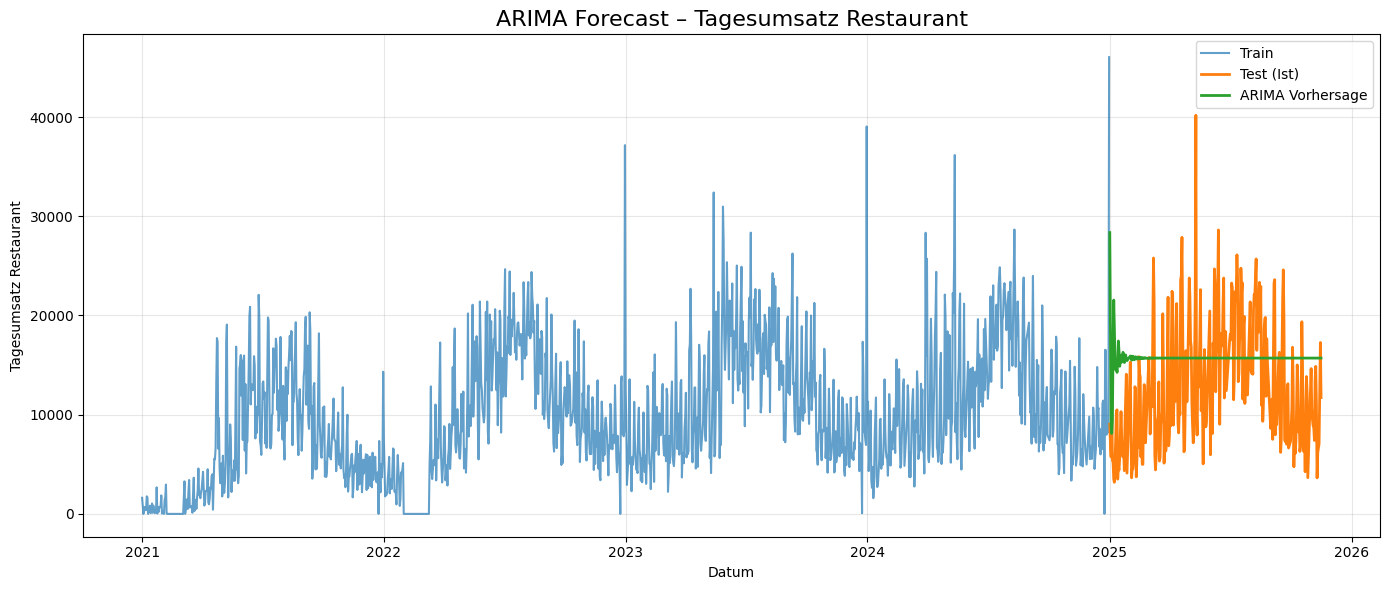

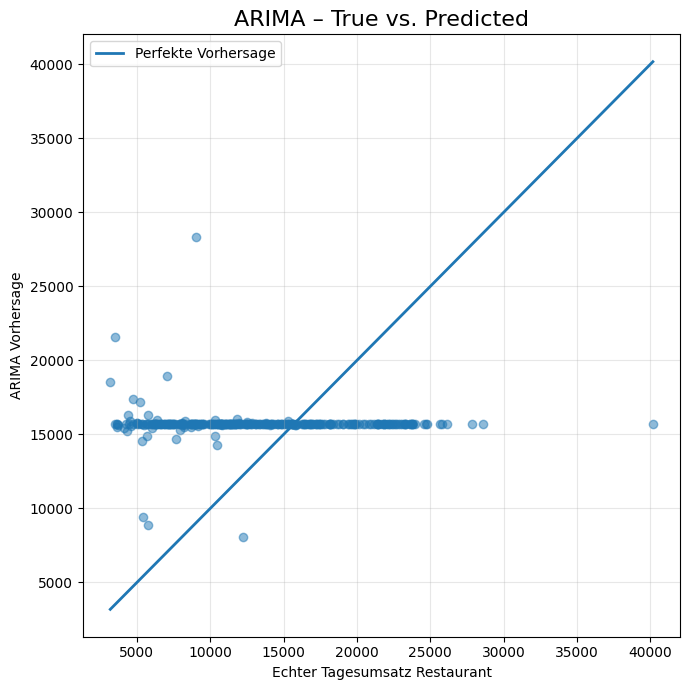

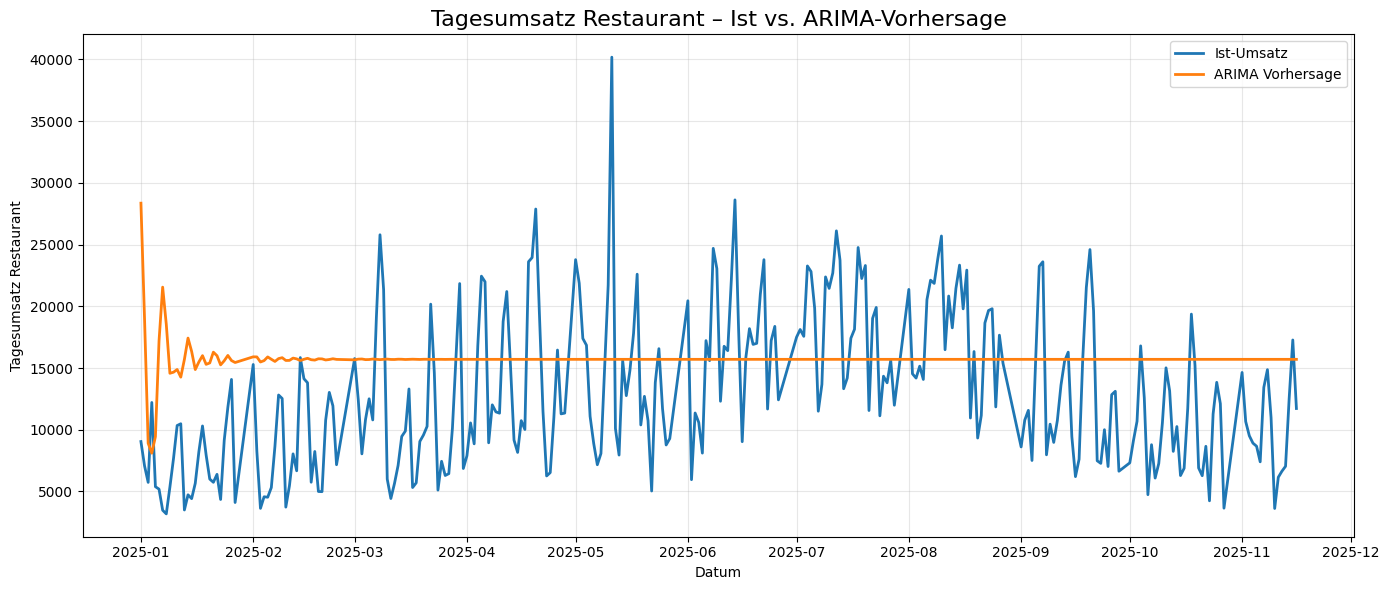

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, r2_score

# 1) Dataset laden
df = pd.read_csv("data/dataset-merged-2.csv")
df["Datum"] = pd.to_datetime(df["Datum"])
df = df.sort_values("Datum")

# 2) Univariate Zeitreihe für ARIMA (Target = Tagesumsatz Restaurant)
ts = df.set_index("Datum")["Tagesumsatz Restaurant"]

# 3) Train / Test Split (zeitbasiert)
split_date = pd.Timestamp("2025-01-01")

train = ts[ts.index < split_date]
test  = ts[ts.index >= split_date]

print("Train length:", len(train))
print("Test length :", len(test))

# 4) ARIMA-Modell fitten
order = (5, 1, 3)   # kann man später noch tunen

model = ARIMA(train, order=order)
model_fit = model.fit()

print(model_fit.summary())

# 5) Forecast über Testperiode
forecast = model_fit.forecast(steps=len(test))

# 6) Evaluation
mse  = mean_squared_error(test, forecast)
rmse = mse ** 0.5
r2   = r2_score(test, forecast)

print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

# 7) Plot: Train, Test (Ist) und Forecast
plt.figure(figsize=(14,6))
plt.plot(train.index, train, label="Train", alpha=0.7)
plt.plot(test.index, test, label="Test (Ist)", linewidth=2)
plt.plot(test.index, forecast, label="ARIMA Vorhersage", linewidth=2)

plt.title("ARIMA Forecast – Tagesumsatz Restaurant", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Tagesumsatz Restaurant")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 8) Scatter Plot: True vs Forecast
plt.figure(figsize=(7,7))
plt.scatter(test.values, forecast.values, alpha=0.5)
plt.plot([min(test), max(test)], [min(test), max(test)],
         linewidth=2, label="Perfekte Vorhersage")

plt.title("ARIMA – True vs. Predicted", fontsize=16)
plt.xlabel("Echter Tagesumsatz Restaurant")
plt.ylabel("ARIMA Vorhersage")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 9) Zeitreihen-Plot: Ist vs. Vorhersage (nur Testperiode, schön kompakt)

results_arima = pd.DataFrame({
    "Datum": test.index,
    "Ist": test.values,
    "Vorhersage": forecast.values
})

plt.figure(figsize=(14,6))
plt.plot(results_arima["Datum"], results_arima["Ist"], 
         label="Ist-Umsatz", linewidth=2)
plt.plot(results_arima["Datum"], results_arima["Vorhersage"], 
         label="ARIMA Vorhersage", linewidth=2)

plt.title("Tagesumsatz Restaurant – Ist vs. ARIMA-Vorhersage", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Tagesumsatz Restaurant")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Train length: 1438
Test length : 289


c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                 SARIMAX Results                                  
Dep. Variable:     Tagesumsatz Restaurant   No. Observations:                 1438
Model:                     ARIMA(5, 1, 3)   Log Likelihood              -13928.028
Date:                    Wed, 26 Nov 2025   AIC                          27874.055
Time:                            18:37:36   BIC                          27921.488
Sample:                                 0   HQIC                         27891.764
                                   - 1438                                         
Covariance Type:                      opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0929      0.048      1.918      0.055      -0.002       0.188
ar.L2         -0.8223      0.045    -18.463      0.000      -0.910      -0.735
ar.L3         -0.007

c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


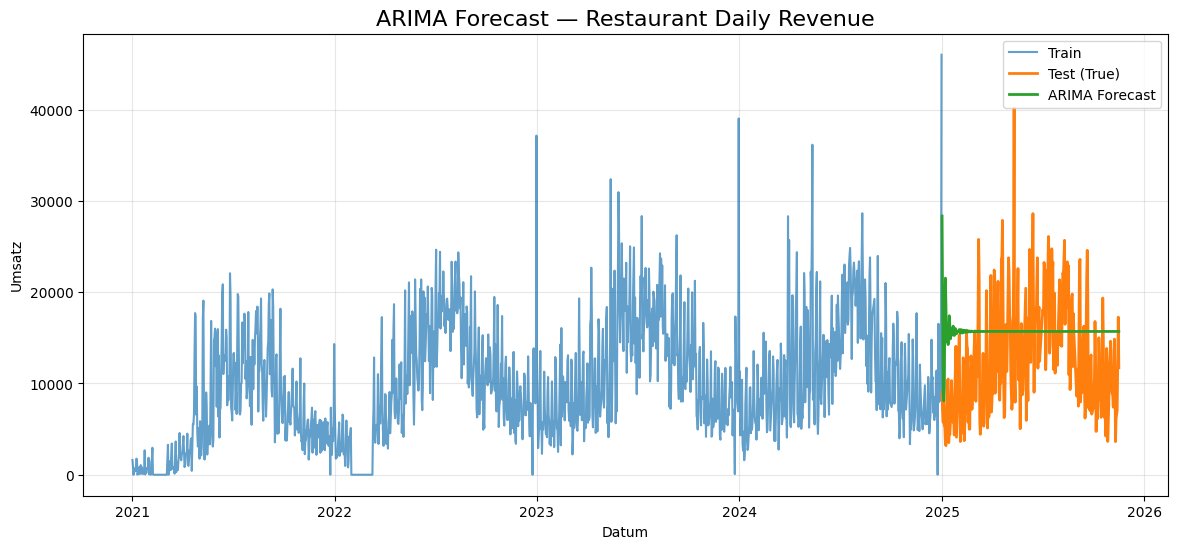

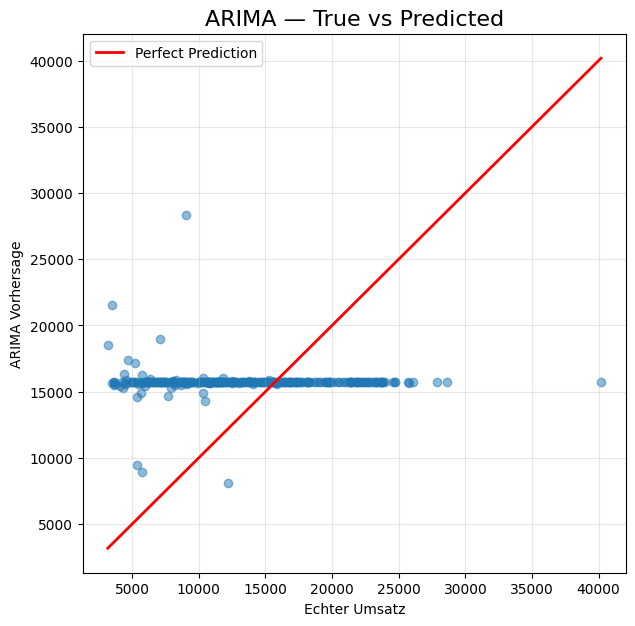

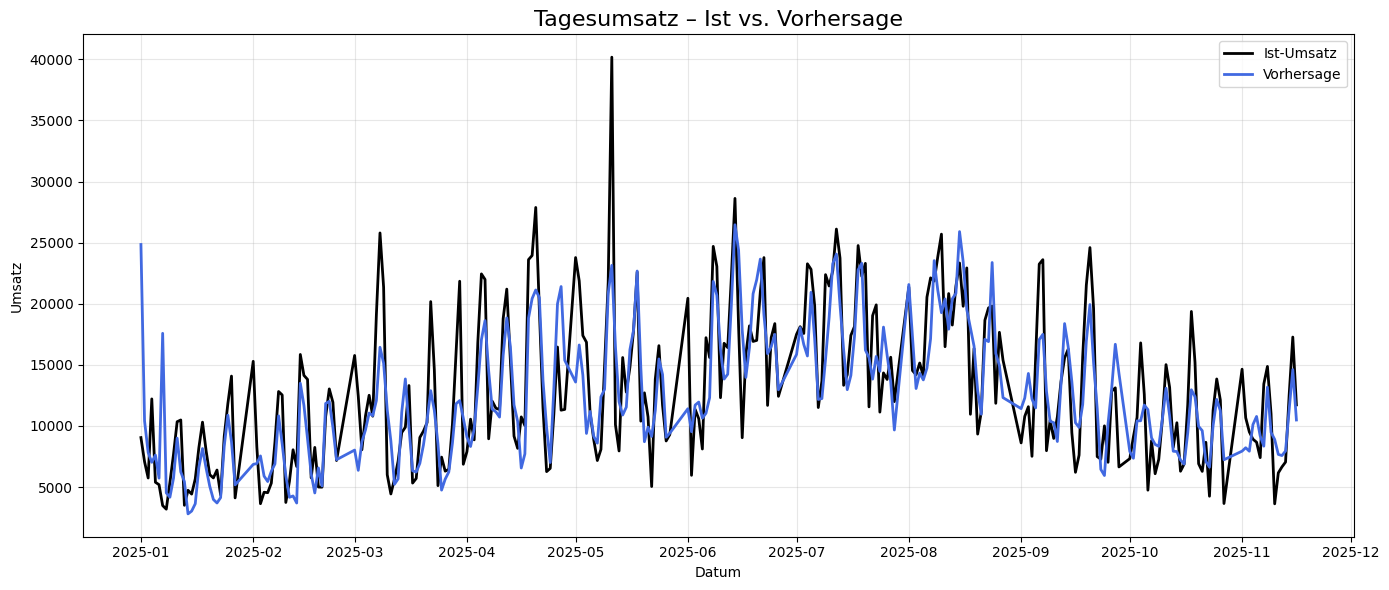

In [8]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, r2_score

# 1) Load dataset
df = pd.read_csv("data/dataset-merged-2.csv")
df["Datum"] = pd.to_datetime(df["Datum"])
df = df.sort_values("Datum")

# 2) Extract univariate time series for ARIMA
ts = df.set_index("Datum")["Tagesumsatz Restaurant"]

# 3) Train / Test Split (time-based)
split_date = pd.Timestamp("2025-01-01")

train = ts[ts.index < split_date]
test  = ts[ts.index >= split_date]

print("Train length:", len(train))
print("Test length :", len(test))

# 4) Fit ARIMA model
# Basic order (Auto-ARIMA would pick automatically, but we choose an initial set)
order = (5, 1, 3)   # You can tune this later

model = ARIMA(train, order=order)
model_fit = model.fit()

print(model_fit.summary())

# 5) Forecast over test period
forecast = model_fit.forecast(steps=len(test))

# 6) Evaluation
mse  = mean_squared_error(test, forecast)
rmse = mse ** 0.5
r2   = r2_score(test, forecast)

print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

# 7) Plot: Forecast vs True Values
plt.figure(figsize=(14,6))
plt.plot(train.index, train, label="Train", alpha=0.7)
plt.plot(test.index, test, label="Test (True)", linewidth=2)
plt.plot(test.index, forecast, label="ARIMA Forecast", linewidth=2)

plt.title("ARIMA Forecast — Restaurant Daily Revenue", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Umsatz")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 8) Scatter Plot: True vs Forecast
plt.figure(figsize=(7,7))
plt.scatter(test.values, forecast.values, alpha=0.5)
plt.plot([min(test), max(test)], [min(test), max(test)],
         color="red", linewidth=2, label="Perfect Prediction")

plt.title("ARIMA — True vs Predicted", fontsize=16)
plt.xlabel("Echter Umsatz")
plt.ylabel("ARIMA Vorhersage")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(14,6))

# Plot Ist (True values)
plt.plot(results["Datum"], results["Ist"], 
         label="Ist-Umsatz", 
         linewidth=2, 
         color="black")

# Plot Forecast
plt.plot(results["Datum"], results["Vorhersage"], 
         label="Vorhersage", 
         linewidth=2, 
         color="royalblue")

plt.title("Tagesumsatz – Ist vs. Vorhersage", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Umsatz")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

LSTM Model

Prophet Model